In [1]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

import os
import sys
import logging
import warnings

/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load file path from ocean
adata_infile = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/All_Cell_Types.h5ad'
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/Myofiber_scsn_RNA.h5ad'
adata_male_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_male.h5ad'
adata_female_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp'

In [55]:
adata_male = sc.read_h5ad(adata_male_file)
#adata_female = sc.read_h5ad(adata_female_file)

# Male and Female Myofibers (size matched young and old samples)

In [56]:
adata_male

AnnData object with n_obs × n_vars = 74348 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'GOBP_DNA_DAMAGE_RESPONSE', 'REACTOME_DNA_REPAIR', 'DNA_DAMAGE_CHECKPOINT', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_

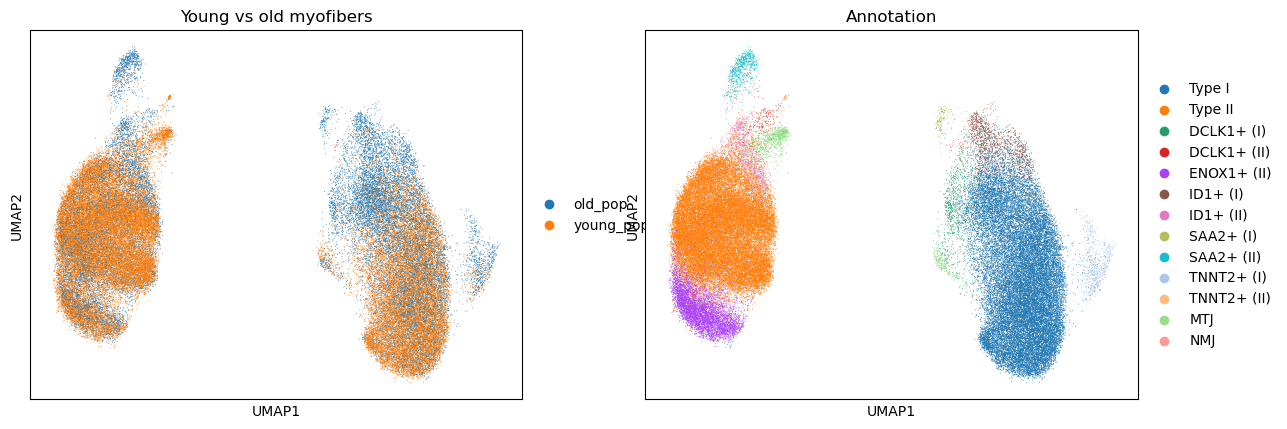

In [57]:
sc.pl.umap(adata_male, color=['age_pop','Annotation'], title='Young vs old myofibers')

In [58]:
# count the number of cells in each age
display(adata_male.obs['sample'].value_counts())

sample
YM3    20055
YM1    16829
OM5    11986
P5      8992
OM7     5693
P13     2949
YM4     2843
OM3     1834
P23     1223
P17     1215
P29      454
OM4      275
Name: count, dtype: int64

# AUCell activity scoring of specific pathways

In [59]:
from pathlib import Path
from itertools import chain, repeat

def gmt_to_decoupler(pth: Path) -> pd.DataFrame:
    """Parse a gmt file to a decoupler pathway dataframe."""
    from itertools import chain, repeat

    pathways = {}

    with Path(pth).open("r") as f:
        for line in f:
            name, _, *genes = line.strip().split("\t")
            pathways[name] = genes

    return pd.DataFrame.from_records(
        chain.from_iterable(zip(repeat(k), v) for k, v in pathways.items()),
        columns=["geneset", "genesymbol"],
    )

def gmt_to_decoupler_multiple_pathways(gmt_paths):
    """Parse multiple gmt files and return a combined decoupler pathway dataframe."""
    all_records = []
    for pth in gmt_paths:
        with Path(pth).open("r") as f:
            for line in f:
                name, _, *genes = line.strip().split("\t")
                all_records.extend(zip(repeat(name), genes))
    return pd.DataFrame.from_records(all_records, columns=["geneset", "genesymbol"])

In [60]:
# load geneset of interest
geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
# get the number of rows in each unique geneset
geneset_size = geneset_df['geneset'].value_counts()
geneset_size


geneset
KEGG_OXIDATIVE_PHOSPHORYLATION                   132
GOBP_FATTY_ACID_BETA_OXIDATION                    75
KEGG_GLYCOLYSIS_GLUCONEOGENESIS                   62
KEGG_CITRATE_CYCLE_TCA_CYCLE                      31
REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM     21
REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM       14
Name: count, dtype: int64

In [28]:
%%time
decoupler.run_aucell(
    adata_female,
    geneset_df,
    source="geneset",
    target="genesymbol",
    use_raw=False,
)

CPU times: user 16min 39s, sys: 36min 38s, total: 53min 17s
Wall time: 5min 35s


In [29]:
# dna_damage_and_repair_pathways = [
#     "DNA_DAMAGE_CHECKPOINT",
#     "GOBP_DNA_DAMAGE_RESPONSE",
#     "GOBP_DNA_REPAIR",
#     "HALLMARK_DNA_REPAIR",
#     "REACTOME_DNA_REPAIR",
#     "REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS"
# ]
metabolic_pathways = [
    "GOBP_FATTY_ACID_BETA_OXIDATION",
    "KEGG_CITRATE_CYCLE_TCA_CYCLE",
    "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
    "KEGG_OXIDATIVE_PHOSPHORYLATION",
    "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
    "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
]
adata_male.obs[metabolic_pathways] = adata_male.obsm["aucell_estimate"][metabolic_pathways]

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

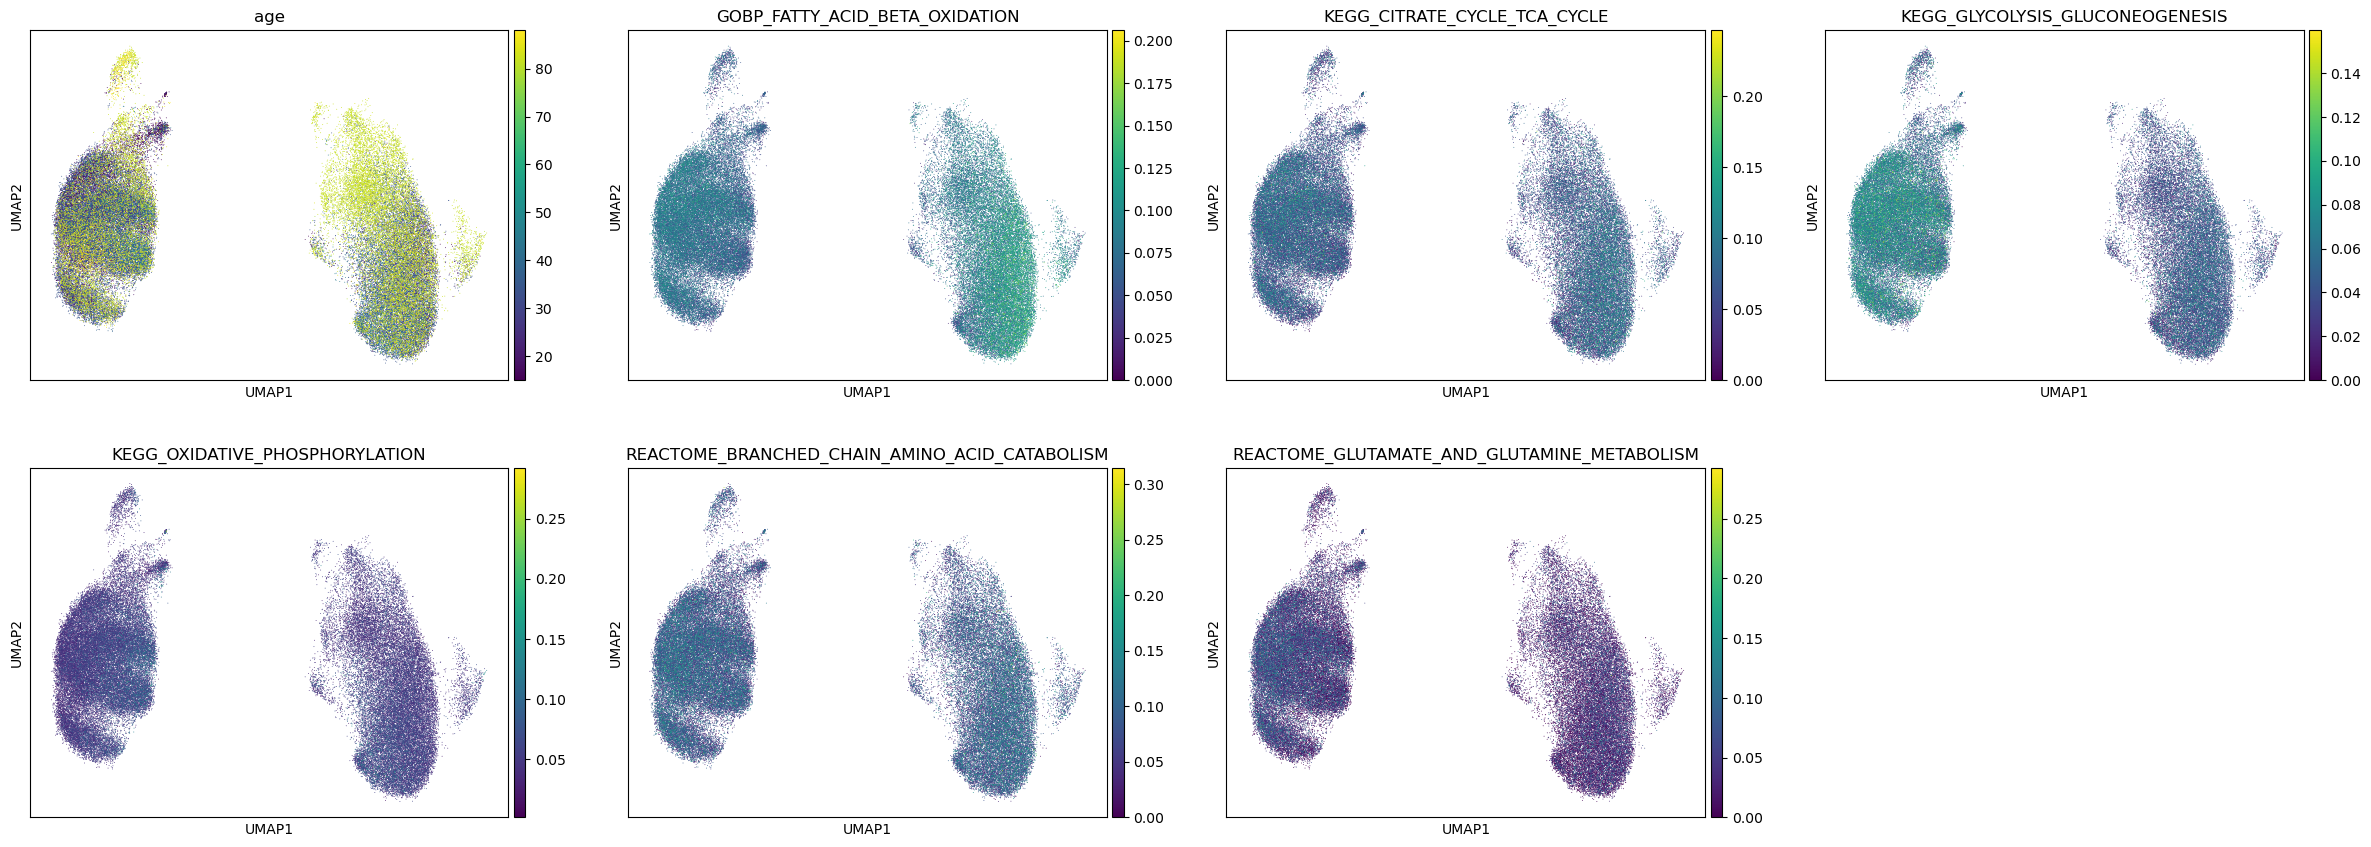

In [61]:
sc.pl.umap(adata_male, color=['age'] + metabolic_pathways)

In [31]:
adata_female

AnnData object with n_obs × n_vars = 76546 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'DNA_DAMAGE_CHECKPOINT', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_

In [32]:
# save adata
adata_female.write_h5ad(os.path.join(out_tmp, 'myofibers_female.h5ad'))

### Plot samples ordered by score to identify outliers

In [42]:
# get a df of sample ID, sample score per cell type and age
sample_scores = adata_female.obs[['sample','age', 'Annotation'] + metabolic_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg

/tmp/ipykernel_61865/3167691292.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()


,sample,Annotation,age,GOBP_FATTY_ACID_BETA_OXIDATION,KEGG_CITRATE_CYCLE_TCA_CYCLE,KEGG_GLYCOLYSIS_GLUCONEOGENESIS,KEGG_OXIDATIVE_PHOSPHORYLATION,REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM,REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM
0,OM1,Type I,82.0,0.094623,0.042959,0.035942,0.053517,0.057156,0.025163
1,OM1,Type II,82.0,0.069320,0.035341,0.053004,0.055891,0.048509,0.031745
2,OM1,DCLK1+ (I),82.0,0.063748,0.038338,0.030588,0.045425,0.030244,0.045130
3,OM1,DCLK1+ (II),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OM1,ENOX1+ (II),82.0,0.085140,0.036051,0.037685,0.039565,0.057102,0.052302
...,...,...,...,...,...,...,...,...,...
125,YM2,SAA2+ (II),34.0,0.073434,0.054285,0.079207,0.045102,0.075213,0.043306
126,YM2,TNNT2+ (I),34.0,0.072306,0.066804,0.038375,0.037085,0.067742,0.019739
127,YM2,TNNT2+ (II),34.0,0.068577,0.074868,0.058598,0.073610,0.076880,0.000000
128,YM2,MTJ,34.0,0.057052,0.048653,0.056365,0.046240,0.050526,0.028664


In [18]:
import matplotlib.pyplot as plt

def plot_multi_score_lines(
    df, 
    score_cols, 
    age_col='age', 
    sample_col='sample', 
    annotation=None, 
    figsize=(14, 7)
):
    """
    Plots multiple scores as colored lines with sample dots, ordered by age.
    
    Parameters:
        df (pd.DataFrame): Input dataframe.
        score_cols (list): List of score column names to plot.
        age_col (str): Column name for age (x-axis).
        sample_col (str): Column name for sample IDs (for labeling).
        annotation (str or None): If provided, subset to this annotation.
        figsize (tuple): Figure size.
    """
    # Optionally subset by annotation
    if annotation is not None:
        df = df[df['Annotation'] == annotation]
    
    # Drop rows with missing age or all scores missing
    df = df.dropna(subset=[age_col] + score_cols)
    # Sort by age
    df = df.sort_values(age_col)
    
    plt.figure(figsize=figsize)
    colors = plt.cm.tab10.colors  # Up to 10 distinct colors
    
    for i, score in enumerate(score_cols):
        y = df[score]
        x = df[age_col]
        plt.plot(x, y, label=score.replace('_', ' '), color=colors[i % len(colors)], marker='o')
        # Optionally, annotate with sample names
        for xi, yi, sample in zip(x, y, df[sample_col]):
            plt.annotate(
                sample, 
                (xi, yi), 
                color=colors[i % len(colors)], 
                fontsize=8, 
                xytext=(0, 5), 
                textcoords="offset points", 
                ha="center"
            )
    
    plt.xlabel('Age')
    plt.ylabel('Score')
    plt.title('Multiple DNA Damage/Repair Scores by Age' + (f' (Annotation: {annotation})' if annotation else ''))
    plt.legend(title='Score')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

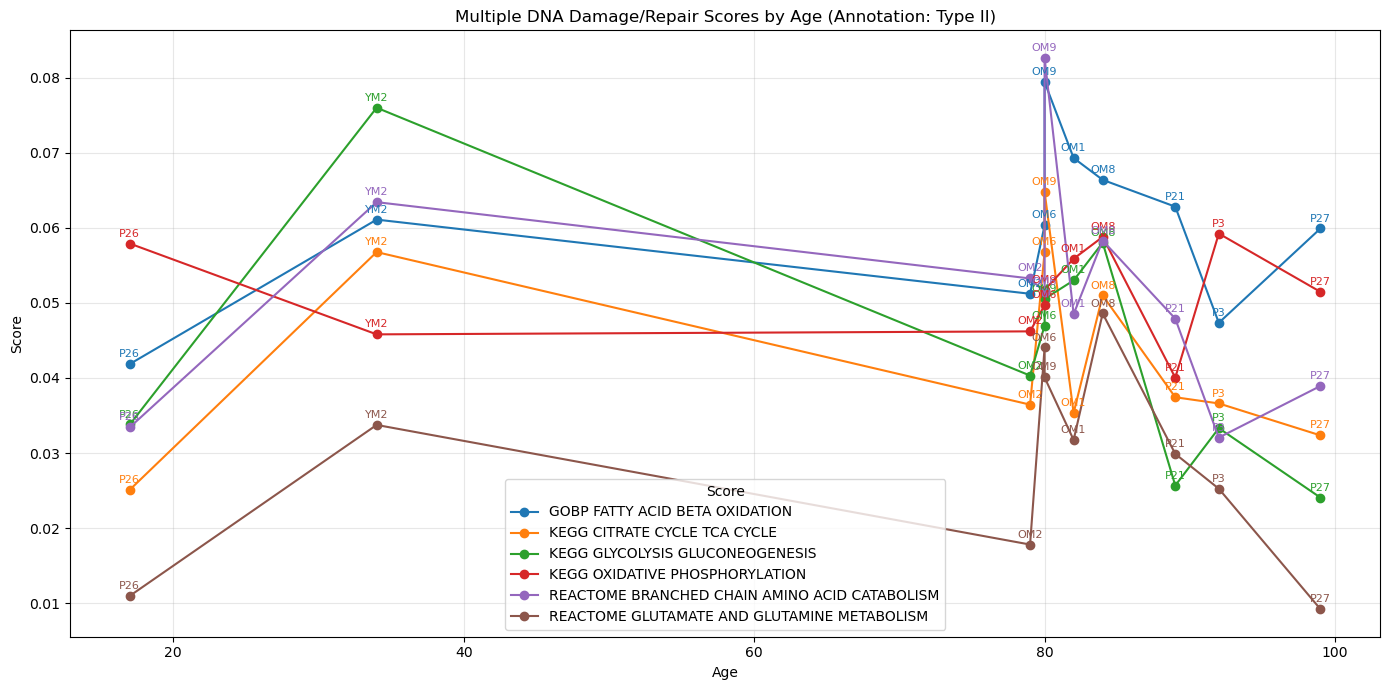

In [35]:
score_cols = metabolic_pathways
plot_multi_score_lines(sample_scores_avg, score_cols, age_col='age', sample_col='sample', annotation='Type II')

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

def plot_pathway_box_distributions_by_age( # Renamed for clarity
    df_cell_level,
    score_cols,
    geneset_sizes,
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation=None,
    filter_quantile_to_keep_top=None,
    n_subplot_cols=2,
    figsize_per_subplot=(8, 6),
    box_width=0.8, # Control width of boxes
    sample_label_fontsize=8,
    sample_label_y_offset_factor=0.05
):
    """
    Plots box plots for multiple pathway scores, with samples positioned by age on x-axis.
    Sample IDs are annotated above the boxes.
    Optionally filters cells to keep only the most active ones per sample per pathway.

    Parameters:
        df_cell_level (pd.DataFrame): Cell-level data.
        score_cols (list): List of score column names to plot.
        geneset_sizes (pd.Series or dict): Maps score_col names to their sizes.
        age_col (str): Column name for age.
        sample_col (str): Column name for sample IDs.
        annotation_col (str): Column name for annotations.
        target_annotation (str or None): If provided, subset to this annotation.
        filter_quantile_to_keep_top (float or None): Quantile of top scores to keep.
        n_subplot_cols (int): Number of columns in the subplot grid.
        figsize_per_subplot (tuple): Figure size for each individual subplot.
        box_width (float): Width of the box plots.
        sample_label_fontsize (int): Fontsize for sample ID labels.
        sample_label_y_offset_factor (float): Factor to adjust y-position of sample labels.
    """
    plot_df = df_cell_level.copy()

    if target_annotation is not None:
        if annotation_col not in plot_df.columns:
            print(f"Warning: Annotation column '{annotation_col}' not found. Cannot filter by '{target_annotation}'.")
            return
        plot_df = plot_df[plot_df[annotation_col] == target_annotation]
        if plot_df.empty:
            print(f"No cells found for annotation '{target_annotation}'.")
            return

    required_cols = [age_col, sample_col] + score_cols
    for col in required_cols:
        if col not in plot_df.columns:
            print(f"Warning: Required column '{col}' not found. Aborting.")
            return

    plot_df = plot_df.dropna(subset=[age_col, sample_col], how='any')
    plot_df = plot_df.dropna(subset=score_cols, how='all')

    if plot_df.empty:
        print("No data to plot after initial NaN filtering.")
        return

    unique_ages_sorted = sorted(plot_df[age_col].unique())
    age_to_xpos = {age: i for i, age in enumerate(unique_ages_sorted)}
    plot_df['x_position'] = plot_df[age_col].map(age_to_xpos)

    xpos_to_samples = plot_df.groupby('x_position')[sample_col].unique().apply(lambda x: '/'.join(sorted(x)))


    num_scores = len(score_cols)
    n_subplot_rows = (num_scores + n_subplot_cols - 1) // n_subplot_cols

    fig, axes = plt.subplots(
        n_subplot_rows,
        n_subplot_cols,
        figsize=(figsize_per_subplot[0] * n_subplot_cols, figsize_per_subplot[1] * n_subplot_rows),
        squeeze=False
    )
    axes = axes.flatten()

    for i, score in enumerate(score_cols):
        ax = axes[i]
        current_score_df = plot_df[['x_position', sample_col, age_col, score]].copy().dropna(subset=[score])

        if current_score_df.empty:
            ax.set_title(f"{score.replace('_', ' ')}\n(No data)")
            ax.axis('off')
            continue

        df_for_plot = current_score_df.copy()

        if filter_quantile_to_keep_top is not None and 0 < filter_quantile_to_keep_top < 1:
            quantile_for_threshold = 1.0 - filter_quantile_to_keep_top
            def filter_by_quantile(group):
                if group.empty or len(group) < 2:
                    return group
                original_sample_group = plot_df[
                    (plot_df[sample_col] == group[sample_col].iloc[0]) &
                    (plot_df[age_col] == group[age_col].iloc[0])
                ][score]
                if original_sample_group.empty or len(original_sample_group) < 2:
                    return group
                threshold_val = original_sample_group.quantile(quantile_for_threshold)
                return group[group[score] >= threshold_val]
            df_for_plot = df_for_plot.groupby([sample_col, age_col], group_keys=False).apply(filter_by_quantile)

            if df_for_plot.empty:
                ax.set_title(f"{score.replace('_', ' ')}\n(No data after filtering)")
                ax.axis('off')
                continue
        
        # --- Changed from violinplot to boxplot ---
        sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size

        ax.set_xticks(list(age_to_xpos.values()))
        ax.set_xticklabels([str(int(ua)) if ua==int(ua) else str(round(ua,1)) for ua in unique_ages_sorted], rotation=45, ha="right")
        ax.set_xlabel('Age')

        # Annotate sample IDs above boxes
        # Determine y-position for labels based on existing data in the current plot
        if not df_for_plot.empty:
            # Consider whisker ends for max y to place labels above.
            # Boxplot calculations for whiskers can be complex, so we take a simpler approach:
            # Use the max data point within 1.5*IQR or the absolute max if no outliers,
            # or simply the max of the data points plotted.
            # A robust way is to find the top of the whiskers if possible, or just use max data for simplicity.
            y_values_in_plot = []
            for x_pos_val in df_for_plot['x_position'].unique():
                y_values_in_plot.extend(df_for_plot[df_for_plot['x_position'] == x_pos_val][score])
            
            if y_values_in_plot:
                max_y_val_for_labeling = np.percentile(y_values_in_plot, 99) # Use 99th percentile to avoid extreme outliers influencing label position too much
                min_y_val_for_labeling = np.percentile(y_values_in_plot, 1)
                y_range = max_y_val_for_labeling - min_y_val_for_labeling
                y_offset = max_y_val_for_labeling + (y_range * sample_label_y_offset_factor) if y_range > 0 else max_y_val_for_labeling * (1 + sample_label_y_offset_factor*2)
            else: # Fallback if no data somehow
                y_offset = ax.get_ylim()[1] * 0.05 # Default offset if no data
        else:
            y_offset = ax.get_ylim()[1] * 0.05


        current_x_positions = sorted(df_for_plot['x_position'].unique())
        for x_pos in current_x_positions:
            sample_names_at_xpos = xpos_to_samples.get(x_pos, "")
            if sample_names_at_xpos:
                 ax.text(x_pos, y_offset, sample_names_at_xpos,
                        ha='center', va='bottom', fontsize=sample_label_fontsize, rotation=90)

        title_text = score.replace('_', ' ')
        size = geneset_sizes.get(score)
        if size is not None:
            title_text += f"\n(n={int(size)})"
        if filter_quantile_to_keep_top is not None:
            title_text += f"\n(Top {filter_quantile_to_keep_top*100:.0f}% cells per sample)"

        ax.set_title(title_text)
        ax.set_ylabel('Score Distribution')
        ax.grid(True, alpha=0.3, axis='y')

    for j in range(num_scores, len(axes)):
        axes[j].axis('off')

    fig_title = 'Pathway Score Distributions by Age'
    if target_annotation:
        fig_title += f' (Annotation: {target_annotation})'
    plt.suptitle(fig_title, fontsize=16, y=1.02 if n_subplot_rows > 1 else 1.05)

    plt.tight_layout(rect=[0, 0, 1, 0.98 if n_subplot_rows > 1 else 0.95])
    plt.show()

In [62]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_male.obs[['sample', 'age', 'Annotation'] + metabolic_pathways].copy()
geneset_sizes_data = {
    'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
    'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
    'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
    'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
    'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
    'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

# Your list of score columns
score_cols_to_plot = list(geneset_sizes_series.index) # or your 'metabolic_pathways' list

/tmp/ipykernel_61865/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size
/tmp/ipykernel_61865/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size
/tmp/ipykernel_61865/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=

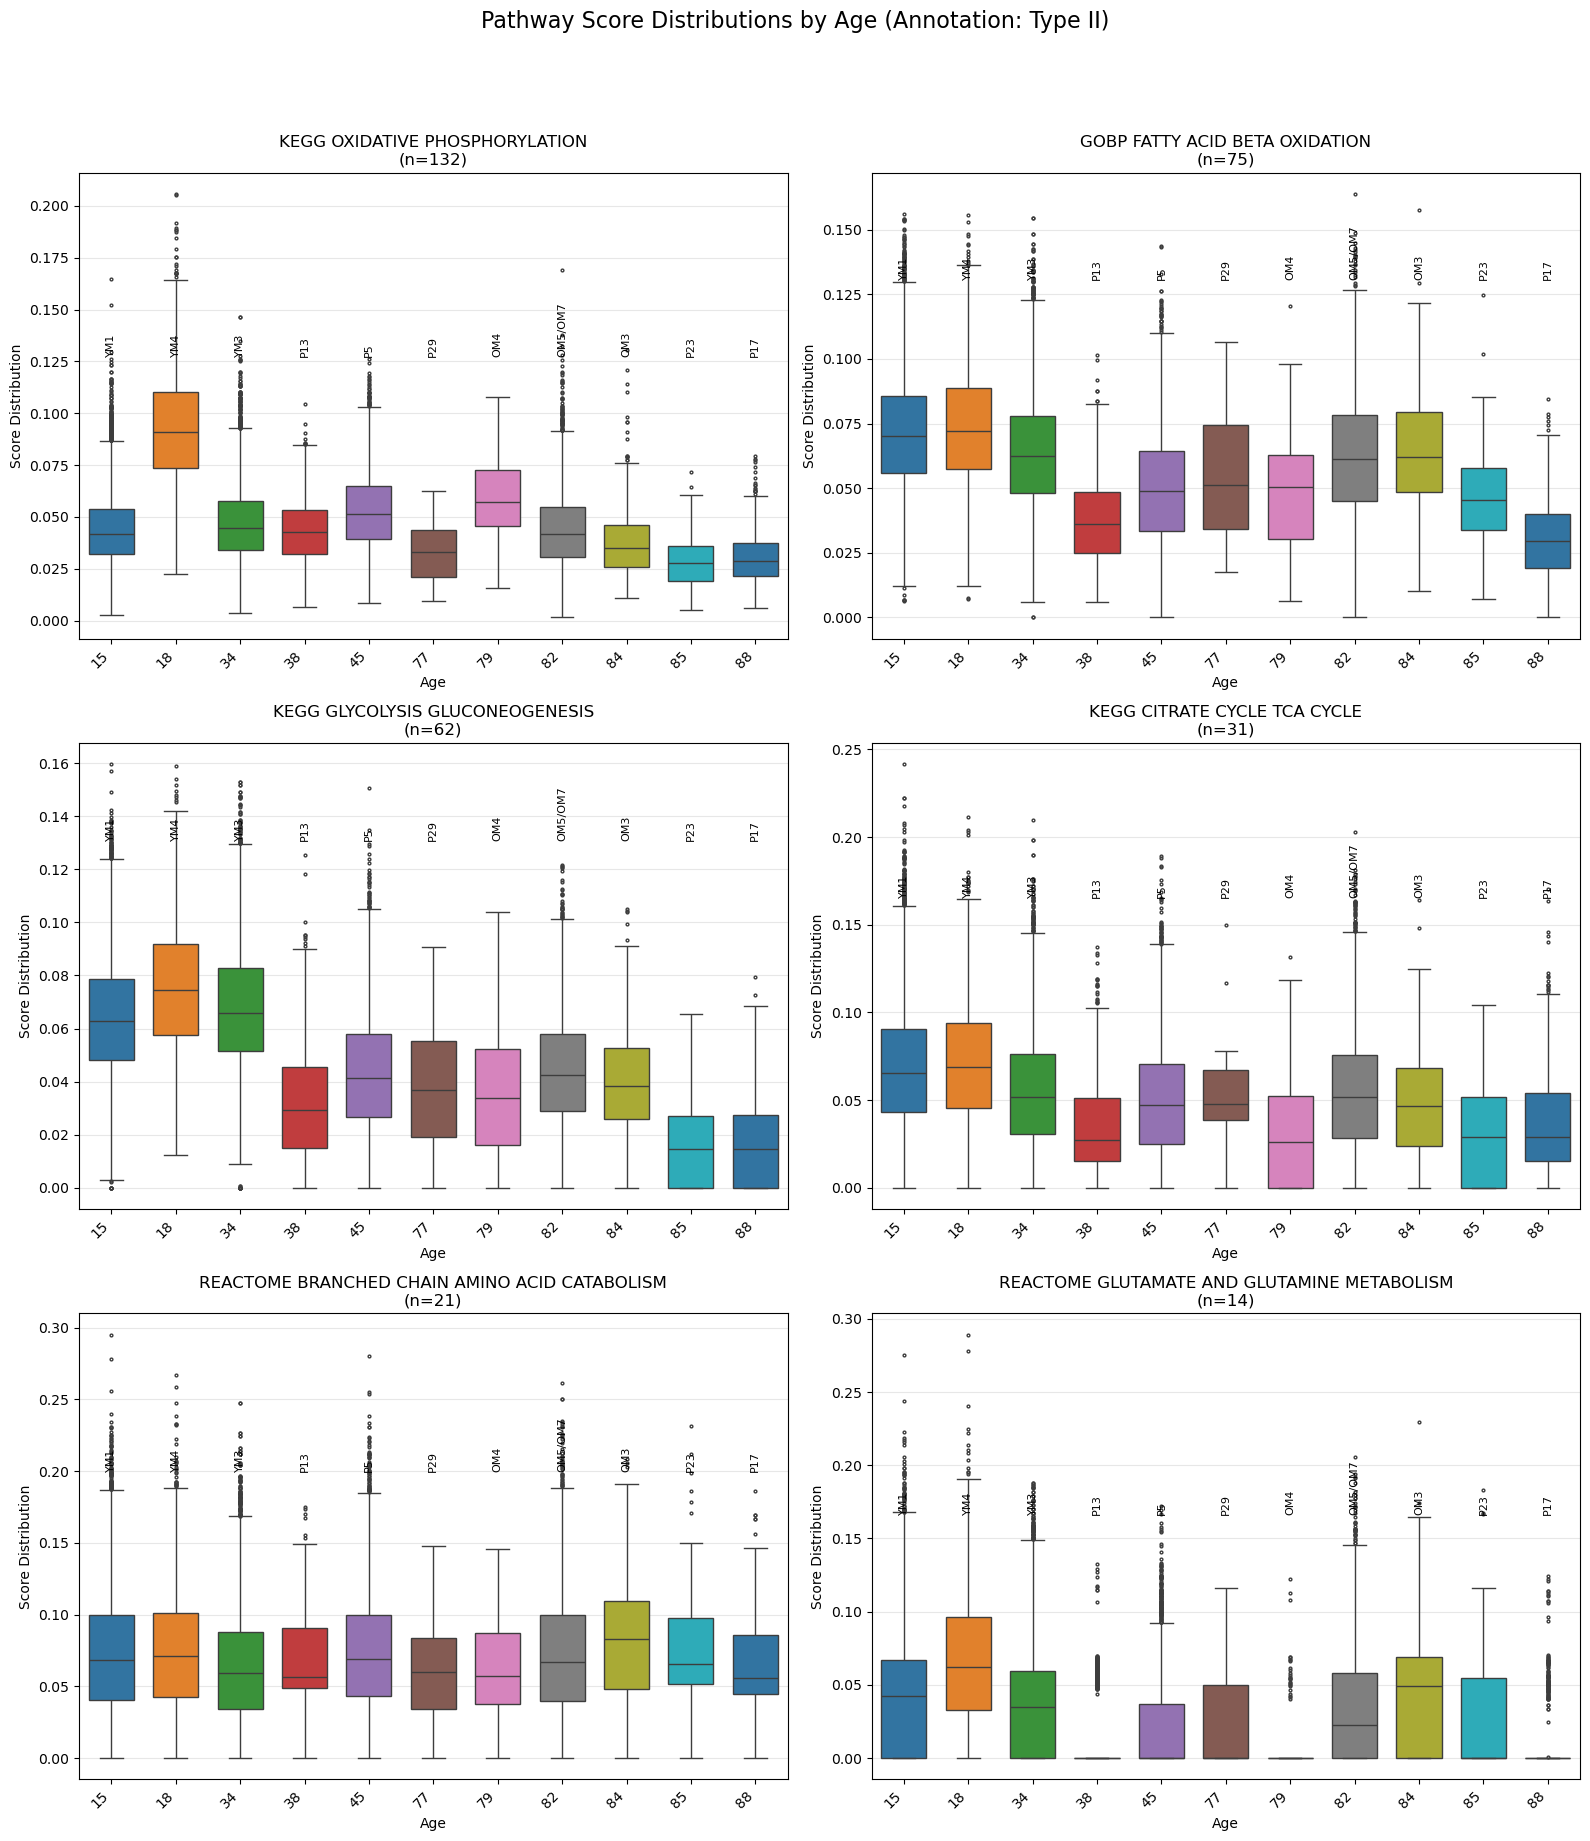

In [64]:
plot_pathway_box_distributions_by_age( # Note the new function name
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    geneset_sizes=geneset_sizes_series,
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation='Type II', # Using 'Type I' as in your image example
    filter_quantile_to_keep_top=None, # or 0.75, etc.
    n_subplot_cols=2, # As in your image example
    box_width=0.7, # Adjust for aesthetics
    sample_label_y_offset_factor=0.08 # May need adjustment
)

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns # For colormap and potentially easier legend handling

def plot_pathway_dotplot_by_age(
    df_cell_level,
    score_cols, # List of pathway score column names
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation=None,
    figsize=(10, 6),
    min_dot_size=20,
    max_dot_size=500,
    dot_size_scale_factor=1.0, # Adjust if sizes are too uniform or too varied
    cmap_name="coolwarm", # Or "RdYlBu_r" to mimic your example more closely
    value_legend_title="Mean Score",
    size_legend_title="# Cells"
):
    """
    Plots a dot plot where dot color is mean pathway score and dot size is number of cells.
    Samples are on x-axis ordered by age, pathways on y-axis.

    Parameters:
        df_cell_level (pd.DataFrame): Cell-level data with scores, age, sample, annotation.
        score_cols (list): List of score column names (pathways).
        age_col (str): Column name for age.
        sample_col (str): Column name for sample IDs.
        annotation_col (str): Column name for annotations.
        target_annotation (str or None): If provided, subset to this annotation.
        figsize (tuple): Figure size.
        min_dot_size (int): Minimum size for dots.
        max_dot_size (int): Maximum size for dots.
        dot_size_scale_factor (float): Multiplier for raw cell counts before scaling to dot size.
        cmap_name (str): Colormap for the scores.
        value_legend_title (str): Title for the colorbar.
        size_legend_title (str): Title for the size legend.
    """
    plot_df = df_cell_level.copy()

    # 1. Data Preparation
    if target_annotation is not None:
        if annotation_col not in plot_df.columns:
            print(f"Warning: Annotation column '{annotation_col}' not found. Cannot filter by '{target_annotation}'.")
            return
        plot_df = plot_df[plot_df[annotation_col] == target_annotation]
        if plot_df.empty:
            print(f"No cells found for annotation '{target_annotation}'.")
            return

    required_cols = [age_col, sample_col, annotation_col] + score_cols
    for col in required_cols:
        if col not in plot_df.columns:
            print(f"Warning: Required column '{col}' not found. Aborting.")
            return

    plot_df = plot_df.dropna(subset=[age_col, sample_col], how='any')
    if plot_df.empty:
        print("No data to plot after initial NaN filtering.")
        return

    # Aggregate: mean scores and cell counts
    grouped = plot_df.groupby(sample_col)
    mean_scores_df = grouped[score_cols].mean()
    cell_counts_series = grouped.size()
    sample_ages_series = grouped[age_col].mean() # Assuming age is consistent per sample

    # Order samples by age
    ordered_samples = sample_ages_series.sort_values().index.tolist()
    if not ordered_samples:
        print("Could not determine sample order.")
        return

    # Prepare data for plotting (long format)
    plot_data_list = []
    for sample_id in ordered_samples:
        for pathway in score_cols:
            mean_score = mean_scores_df.loc[sample_id, pathway] if sample_id in mean_scores_df.index else np.nan
            cell_count = cell_counts_series.loc[sample_id] if sample_id in cell_counts_series.index else 0
            age = sample_ages_series.loc[sample_id] if sample_id in sample_ages_series.index else np.nan
            plot_data_list.append({
                'sample': sample_id,
                'pathway': pathway,
                'mean_score': mean_score,
                'cell_count': cell_count,
                'age': age
            })
    plot_data_df = pd.DataFrame(plot_data_list)
    plot_data_df = plot_data_df.dropna(subset=['mean_score']) # Drop if score couldn't be calculated

    if plot_data_df.empty:
        print("No data to plot after aggregation.")
        return

    # Scale cell counts for dot sizes
    min_count = plot_data_df['cell_count'].min()
    max_count = plot_data_df['cell_count'].max()
    if max_count == min_count : # Avoid division by zero if all counts are the same
         plot_data_df['dot_size'] = min_dot_size if max_count == 0 else (min_dot_size + max_dot_size) / 2
    else:
        # Apply scale factor first
        scaled_counts = plot_data_df['cell_count'] * dot_size_scale_factor
        # Then normalize and scale to dot size range
        # Handle cases where scaled_counts might still be uniform after scaling factor
        min_s_count = scaled_counts.min()
        max_s_count = scaled_counts.max()
        if max_s_count == min_s_count:
             plot_data_df['dot_size'] = min_dot_size if max_s_count == 0 else (min_dot_size + max_dot_size) / 2
        else:
            plot_data_df['dot_size'] = min_dot_size + \
                (scaled_counts - min_s_count) / (max_s_count - min_s_count) * (max_dot_size - min_dot_size)


    # 2. Plotting
    fig, ax = plt.subplots(figsize=figsize)

    # Get unique pathway names for y-axis (preserve order from score_cols)
    pathway_names = score_cols
    pathway_y_coords = {name: i for i, name in enumerate(pathway_names)}

    # Get unique sample names for x-axis (already ordered by age)
    sample_x_coords = {name: i for i, name in enumerate(ordered_samples)}

    scatter = ax.scatter(
        x=plot_data_df['sample'].map(sample_x_coords),
        y=plot_data_df['pathway'].map(pathway_y_coords),
        s=plot_data_df['dot_size'],
        c=plot_data_df['mean_score'],
        cmap=cmap_name,
        edgecolors='gray', # Optional: add edge to dots
        linewidths=0.5    # Optional: edge width
    )

    # --- X-axis (Samples) ---
    ax.set_xticks(list(sample_x_coords.values()))
    ax.set_xticklabels(ordered_samples, rotation=45, ha="right")
    ax.set_xlabel("Sample (Ordered by Age)")

    # --- Age annotations on top ---
    ax2 = ax.twiny() # Create a second x-axis sharing the y-axis
    ax2.set_xlim(ax.get_xlim()) # Ensure limits match
    ax2.set_xticks(list(sample_x_coords.values()))
    ax2.set_xticklabels([f"{sample_ages_series[s]:.0f}" for s in ordered_samples], rotation=45, ha="left")
    ax2.set_xlabel("Age")

    # --- Y-axis (Pathways) ---
    ax.set_yticks(list(pathway_y_coords.values()))
    # Clean up pathway names for display
    clean_pathway_names = [p.replace('KEGG_', '').replace('GOBP_', '').replace('REACTOME_', '').replace('_', ' ').title() for p in pathway_names]
    ax.set_yticklabels(clean_pathway_names)
    ax.set_ylabel("Metabolic Pathway")

    # --- Colorbar for Mean Score ---
    cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.15) # Adjust fraction and pad
    cbar.set_label(value_legend_title)

    # --- Legend for Dot Size (# Cells) ---
    # Create some proxy artists for the legend
    # Define some representative cell counts for the legend
    if max_count > 0 :
        legend_counts_raw = np.linspace(min_count, max_count, num=4, dtype=int)
        # Ensure 0 is included if min_count is 0 and it's meaningful
        if min_count == 0 and 0 not in legend_counts_raw and len(legend_counts_raw) > 1:
            legend_counts_raw[0] = 0
        legend_counts_raw = np.unique(legend_counts_raw) # Ensure unique values
    else: # Handle case where all counts are 0 or only one value
        legend_counts_raw = np.array([min_count]) if min_count > 0 else np.array([0])


    legend_dots = []
    legend_labels = []
    for count_val in legend_counts_raw:
        if max_count == min_count:
            size_val = min_dot_size if max_count == 0 else (min_dot_size + max_dot_size) / 2
        else:
            scaled_c = count_val * dot_size_scale_factor
            size_val = min_dot_size + \
                       (scaled_c - (min_count*dot_size_scale_factor)) / ((max_count*dot_size_scale_factor) - (min_count*dot_size_scale_factor)) * (max_dot_size - min_dot_size)
        size_val = max(min_dot_size, min(max_dot_size, size_val)) # Ensure it's within bounds

        legend_dots.append(plt.scatter([], [], s=size_val, c='gray', label=f"{int(count_val)}")) # Use gray for legend dots
        #legend_labels.append(f"{int(count_val)}") # No need, label is in scatter call

    # Position the size legend to the right, below the colorbar
    # The legend function needs handles and labels. We just pass the handles.
    size_leg = ax.legend(handles=legend_dots, title=size_legend_title,
                         bbox_to_anchor=(1.18, 0.4), loc='center left', # Adjust bbox_to_anchor
                         labelspacing=1.5, borderpad=1, frameon=True,
                         handletextpad=1.5, # Increase spacing between dot and text
                         scatterpoints=1) # Ensure only one dot per legend item

    # Adjust layout
    fig_title = f'Pathway Activity Dot Plot (Annotation: {target_annotation})' if target_annotation else 'Pathway Activity Dot Plot'
    plt.suptitle(fig_title, fontsize=16, y=1.05)
    plt.subplots_adjust(top=0.85, bottom=0.15, right=0.8) # Adjust subplot to make space for legends/title
    plt.grid(True, linestyle='--', alpha=0.5, axis='y') # Add y-axis grid
    ax.tick_params(axis='both', which='major', pad=7)
    ax2.tick_params(axis='x', which='major', pad=7)

    plt.show()

/tmp/ipykernel_61865/493146232.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby(sample_col)


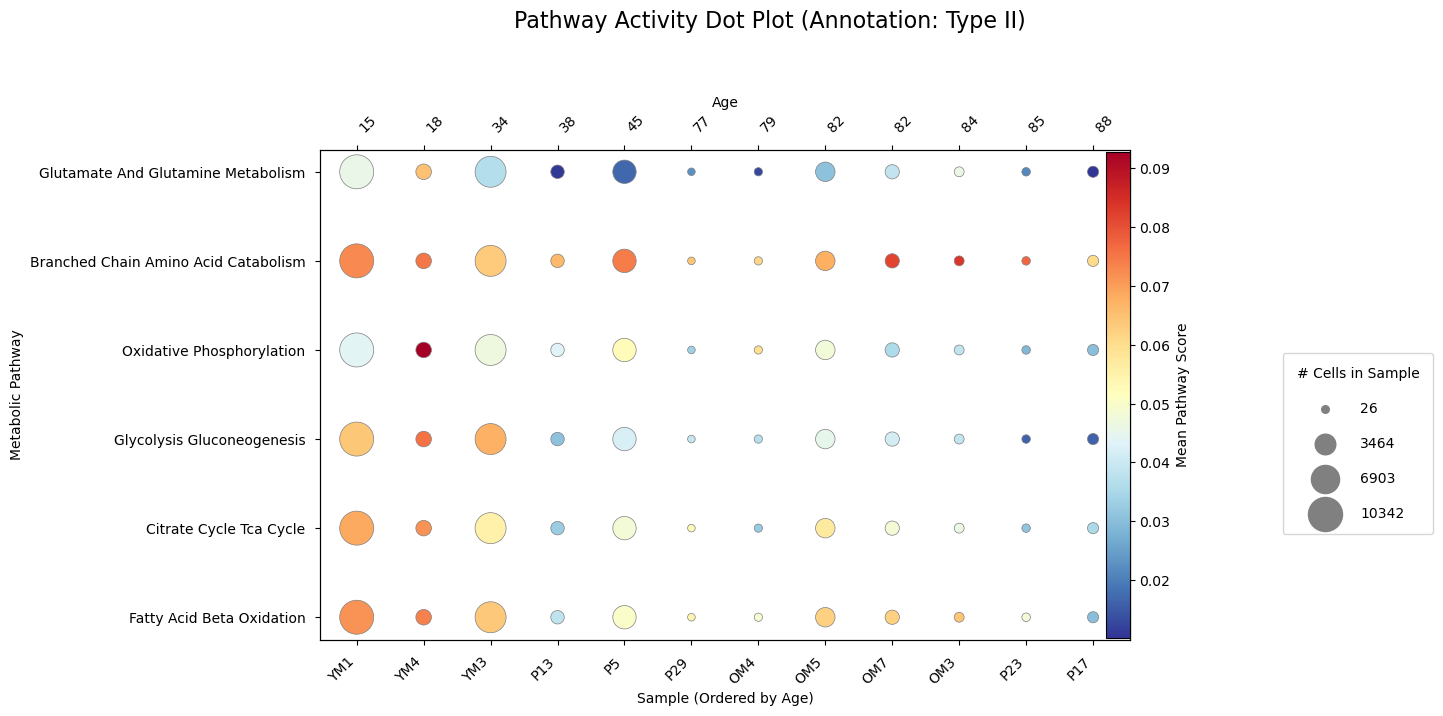

In [66]:
plot_pathway_dotplot_by_age(
    df_cell_level=cell_level_scores_df, # Your cell-level data
    score_cols=metabolic_pathways,      # List of pathway score columns
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation='Type II',         # Or whichever annotation you want
    figsize=(12, 7),                    # Adjust figure size
    min_dot_size=30,
    max_dot_size=600,
    dot_size_scale_factor=0.1, # YOU WILL LIKELY NEED TO TUNE THIS FACTOR!
                               # If cell counts are very large (e.g., 1000s),
                               # this factor should be small (e.g., 0.01, 0.1).
                               # If cell counts are small (e.g., 10s, 100s),
                               # this factor can be larger (e.g., 1.0, 5.0).
                               # The goal is to get a good visual spread of dot sizes.
    cmap_name="RdYlBu_r",               # Red-Yellow-Blue reversed, hot is red
    value_legend_title="Mean Pathway Score",
    size_legend_title="# Cells in Sample"
)

# DEGs and gsea pathway analysis

#### Do size matching to get a more balanced sample size for DEG significance

In [ ]:
adata_male_size_matched = adata_male[~adata_male.obs['orig.ident'].str.startswith('P17')]
adata_male_size_matched
# adata_female_size_matched = adata_female[adata_female.obs['age'].isin([18,25,34,89,90,99])]
# adata_female_size_matched

In [ ]:
adata_male_size_matched.obs['age_pop'] = pd.Categorical(adata_male_size_matched.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)

In [ ]:
bdata = adata_male_size_matched[adata_male_size_matched.obs.Annotation == "Type II"].copy()
bdata

In [161]:
sc.tl.rank_genes_groups(bdata,
                        groupby='age_pop',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["old_pop"],
                        reference='young_pop')

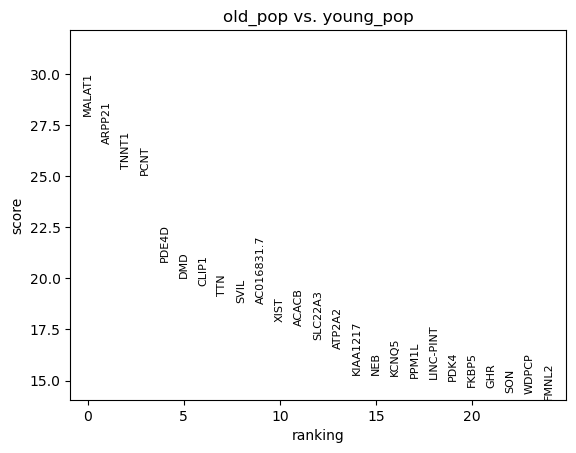

In [162]:
sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False)

In [163]:
# get deg result
result = bdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs.head()

,old_pop_names,old_pop_scores,old_pop_pvals,old_pop_pvals_adj,old_pop_logfoldchanges
0,MALAT1,27.968523,3.924912e-172,2.108768e-168,0.521816
1,ARPP21,26.562567,1.838646e-155,6.839055e-152,2.794163
2,TNNT1,25.339315,1.178625e-141,3.799494e-138,5.433575
3,PCNT,25.066235,1.161599e-138,3.510569e-135,1.491598
4,PDE4D,20.794600,4.843774e-96,5.323197e-93,0.331689


In [164]:
# subset up or down regulated genes
degs_sig = degs[degs.old_pop_pvals_adj < 0.01]
degs_up = degs_sig[degs_sig.old_pop_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.old_pop_logfoldchanges < 0]

In [165]:
degs_up.shape

(202, 5)

In [166]:
degs_dw.shape

(1175, 5)

In [173]:
enr_up = gp.enrichr(degs_up.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [174]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Sarcoplasmic Reticulum Calcium Ion Transport (...,3/10,0.000116,0.047481,0,0,42.622398,386.386493,ATP2A2;RYR3;TRDN
1,GO_Biological_Process_2025,Neurotransmitter Uptake (GO:0001504),3/11,0.000158,0.047481,0,0,37.292714,326.473470,SLC22A3;SLC38A1;SLC1A3
2,GO_Biological_Process_2025,Regulation of Microtubule Polymerization (GO:0...,5/53,0.000194,0.047481,0,0,10.443105,89.284921,CLIP1;SLTM;AKAP9;KIF21A;CDK5RAP2
3,GO_Biological_Process_2025,Vascular Transport (GO:0010232),6/84,0.000208,0.047481,0,0,7.739403,65.607502,SLC22A3;SLC38A1;SLC22A5;SLC7A8;ABCC5;SLC1A3
4,GO_Biological_Process_2025,L-amino Acid Transport (GO:0015807),4/30,0.000225,0.047481,0,0,15.362859,129.017643,SLC38A1;SLC7A6;SLC7A8;SLC1A3
...,...,...,...,...,...,...,...,...,...,...
1198,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,2/455,0.946222,0.949379,0,0,0.427042,0.023606,FAF1;CCAR1
1199,GO_Biological_Process_2025,Protein-Containing Complex Assembly (GO:0065003),1/323,0.963325,0.965733,0,0,0.300918,0.011244,DMD
1200,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,1/340,0.969228,0.970842,0,0,0.285578,0.008926,FAF1
1201,GO_Biological_Process_2025,Protein Modification Process (GO:0036211),2/545,0.975392,0.976203,0,0,0.354604,0.008835,MAST2;SIK2


<>:3: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_48111/2919268616.py:3: SyntaxWarning: invalid escape sequence '\('
  enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]


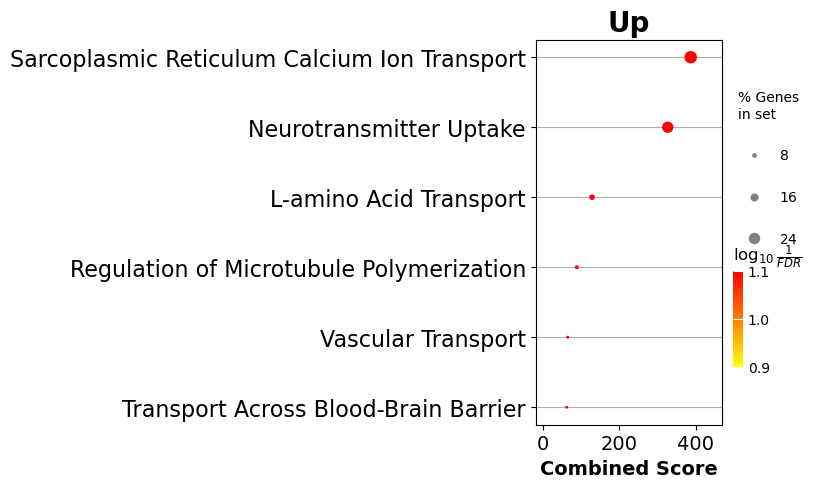

In [176]:
# dotplot
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(3,5), title="Up", cmap = plt.cm.autumn_r)
plt.show()

In [178]:
enr_dw = gp.enrichr(degs_dw.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [179]:
enr_dw.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Myofibril Assembly (GO:0030239),27/51,2.549932e-20,8.271980e-17,0,0,18.424325,8.312251e+02,MYOM1;FLII;LMOD1;LMOD3;MYOM2;MYPN;LMOD2;MYOM3;...
1,GO_Biological_Process_2025,Muscle Contraction (GO:0006936),35/97,4.353673e-19,7.061657e-16,0,0,9.291242,3.928160e+02,RYR1;MYLK2;SMPX;LMOD1;LMOD3;MYOM2;CLCN1;LMOD2;...
2,GO_Biological_Process_2025,Actomyosin Structure Organization (GO:0031032),27/85,1.764734e-13,1.908265e-10,0,0,7.610071,2.234744e+02,MYOM1;FLII;LMOD1;LMOD3;MYOM2;MYPN;LMOD2;MYOM3;...
3,GO_Biological_Process_2025,Sarcomere Organization (GO:0045214),17/34,9.514150e-13,7.715975e-10,0,0,16.241796,4.495863e+02,MYOM1;MYBPC1;MYBPC2;TPM1;MYOM2;MYPN;LMOD2;MYOM...
4,GO_Biological_Process_2025,Striated Muscle Contraction (GO:0006941),18/55,1.103278e-09,7.158068e-07,0,0,7.899834,1.629339e+02,RYR1;MYLK2;DTNA;SMPX;PGAM2;TNNC2;TPM1;STAC3;AT...
...,...,...,...,...,...,...,...,...,...,...
3239,GO_Biological_Process_2025,Antimicrobial Humoral Immune Response Mediated...,1/116,9.991248e-01,9.999942e-01,0,0,0.138582,1.213377e-04,GAPDH
3240,GO_Biological_Process_2025,Defense Response to Bacterium (GO:0042742),4/221,9.991985e-01,9.999942e-01,0,0,0.292916,2.348675e-04,MAVS;TFEB;XIAP;OPTN
3241,GO_Biological_Process_2025,Antimicrobial Humoral Response (GO:0019730),1/147,9.998651e-01,9.999942e-01,0,0,0.108976,1.470520e-05,GAPDH
3242,GO_Biological_Process_2025,DNA Repair (GO:0006281),4/302,9.999825e-01,9.999942e-01,0,0,0.212369,3.717934e-06,VCP;UBE2B;ZBTB1;RAD23B


<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_48111/1711771011.py:1: SyntaxWarning: invalid escape sequence '\('
  enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]


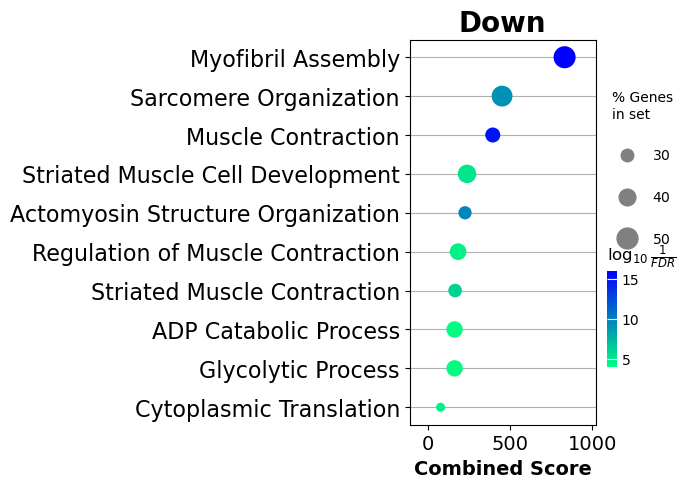

In [180]:
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d,
           figsize=(3,5),
           title="Down",
           cmap = plt.cm.winter_r,
           size=5)
plt.show()